# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

## Подготовка данных

### Импорт библиотек

In [1]:
import pandas as pd 
import numpy as np 
import optuna
from functools import partial
import time
import matplotlib.pyplot as plt 
import seaborn as sns
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    cross_validate
)
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)
from optuna import distributions
from optuna.integration import OptunaSearchCV

### Загрузка данных

In [2]:
try:
    data = pd.read_csv('./autos.csv')
except:
    data = pd.read_csv('/datasets/autos.csv')

Вывод первых строк и размера датасета датасета

In [3]:
display(data.head())
print(data.shape)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


(354369, 16)


Признаки
* `DateCrawled` — дата скачивания анкеты из базы
* `VehicleType` — тип автомобильного кузова
* `RegistrationYear` — год регистрации автомобиля
* `Gearbox` — тип коробки передач
* `Power` — мощность (л. с.)
* `Model` — модель автомобиля
* `Kilometer` — пробег (км)
* `RegistrationMonth` — месяц регистрации автомобиля
* `FuelType` — тип топлива
* `Brand` — марка автомобиля
* `Repaired` — была машина в ремонте или нет
* `DateCreated` — дата создания анкеты
* `NumberOfPictures` — количество фотографий автомобиля
* `PostalCode` — почтовый индекс владельца анкеты (пользователя)
* `LastSeen` — дата последней активности пользователя

Целевой признак

`Price` — цена (евро)

### Анализ пропущенных значений

Число пропусков в каждом их столбцов

In [4]:
data.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

Количество уникальных значений в столбцах с пропусками

In [5]:
data.loc[:, ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Repaired']].nunique()

VehicleType      8
Gearbox          2
Model          250
FuelType         7
Repaired         2
dtype: int64

Частоты значений и количество пропусков для столбцов с пропусками `VehicleType`, `Gearbox`, `FuelType`, `Repaired`

In [6]:
for column in ['VehicleType', 'Gearbox', 'FuelType', 'Repaired']:
    print(column)
    display(data.loc[:, column].value_counts())
    print('Число пропусков =', data.loc[:, column].isna().sum())
    print()
    print('-----------------------------------------')
    print()

VehicleType


VehicleType
sedan          91457
small          79831
wagon          65166
bus            28775
convertible    20203
coupe          16163
suv            11996
other           3288
Name: count, dtype: int64

Число пропусков = 37490

-----------------------------------------

Gearbox


Gearbox
manual    268251
auto       66285
Name: count, dtype: int64

Число пропусков = 19833

-----------------------------------------

FuelType


FuelType
petrol      216352
gasoline     98720
lpg           5310
cng            565
hybrid         233
other          204
electric        90
Name: count, dtype: int64

Число пропусков = 32895

-----------------------------------------

Repaired


Repaired
no     247161
yes     36054
Name: count, dtype: int64

Число пропусков = 71154

-----------------------------------------



Стратегия заполнения пропусков:
* `VehicleType` - не можем определить тип кузова по другим полям; если заполним пропуски самым частым значением, то заметно исказим доли разных кузовов. Заполняем отдельной категорией `unknown`
* `Gearbox` - не можем определить тип коробки передач по другим полям; можем заполнять пропуски как `наиболее встречаемым значением` (число строк с таким значением вырастет менее, чем на 10%), так и отдельной категорией `unknown`. Для простоты заполним `наиболее встречаемым значением`.
* `FuelType` - не можем определить тип топлива по другим полям; можем заполнить пропуски как `наиболее встречаемым значением` (количество пропусков составляем примерно 15% от числа строк с самым частым значением), так и специальным значением `unknown`. Для этого поля выберем вариант с `unknown`.
* `Repaired` - сложно определить причину отсутствия информации о ремонте (потеря данных; отсутствие ремонта как смысл пропуска; отсутствие значения, чтобы не указывать наличие ремонта); если заполним все пропуски одним конкретным значением, то заметно исказим доли значений. Заполняем отдельным значением `unknown`.

5 наиболее встречаемых значений и число пропусков в поле `Model`

In [7]:
display(data['Model'].value_counts().head())
print('Число пропусков =', data['Model'].isna().sum())


Model
golf     29232
other    24421
3er      19761
polo     13066
corsa    12570
Name: count, dtype: int64

Число пропусков = 19705


* `Model` - число пропусков слишком большое в сравнении с количеством объявлений для каждой конкретной модели, так что заполняем пропуски значением `unknown`.

### Заполнение пропущенных значений

In [8]:
data['VehicleType'] = data['VehicleType'].fillna('unknown')
data['Gearbox'] = data['Gearbox'].fillna(data['Gearbox'].mode()[0])
#data['Gearbox'] = data['Gearbox'].fillna('unknown')
data['FuelType'] = data['FuelType'].fillna('unknown')
data['Repaired'] = data['Repaired'].fillna('unknown')
data['Model'] = data['Model'].fillna('unknown') 

Проверка

In [9]:
data.isna().sum()

DateCrawled          0
Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Kilometer            0
RegistrationMonth    0
FuelType             0
Brand                0
Repaired             0
DateCreated          0
NumberOfPictures     0
PostalCode           0
LastSeen             0
dtype: int64

### Анализ дубликатов в данных

In [10]:
data.duplicated().sum()

4

In [11]:
data[data.duplicated(keep=False)]

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
41529,2016-03-18 18:46:15,1999,wagon,2001,manual,131,passat,150000,7,gasoline,volkswagen,no,2016-03-18 00:00:00,0,36391,2016-03-18 18:46:15
88087,2016-03-08 18:42:48,1799,coupe,1999,auto,193,clk,20000,7,petrol,mercedes_benz,no,2016-03-08 00:00:00,0,89518,2016-03-09 09:46:57
90964,2016-03-28 00:56:10,1000,small,2002,manual,83,other,150000,1,petrol,suzuki,no,2016-03-28 00:00:00,0,66589,2016-03-28 08:46:21
171088,2016-03-08 18:42:48,1799,coupe,1999,auto,193,clk,20000,7,petrol,mercedes_benz,no,2016-03-08 00:00:00,0,89518,2016-03-09 09:46:57
187735,2016-04-03 09:01:15,4699,coupe,2003,auto,218,clk,125000,6,petrol,mercedes_benz,yes,2016-04-03 00:00:00,0,75196,2016-04-07 09:44:54
231258,2016-03-28 00:56:10,1000,small,2002,manual,83,other,150000,1,petrol,suzuki,no,2016-03-28 00:00:00,0,66589,2016-03-28 08:46:21
258109,2016-04-03 09:01:15,4699,coupe,2003,auto,218,clk,125000,6,petrol,mercedes_benz,yes,2016-04-03 00:00:00,0,75196,2016-04-07 09:44:54
325651,2016-03-18 18:46:15,1999,wagon,2001,manual,131,passat,150000,7,gasoline,volkswagen,no,2016-03-18 00:00:00,0,36391,2016-03-18 18:46:15


Нашлось 4 явных дубликата, удалим их

In [12]:
data = data.drop_duplicates()

Проверка

In [13]:
data.duplicated().sum()

0

### Проверка правильности типов значений в столбцах

In [14]:
def values_and_type(data):
    dict_to_df = {'column_name': [], 'type': [], 'value_1': [], 'value_2': [], 'value_3': [], 'value_4': [], 'value_5': []}
    for column in data.columns:
        dict_to_df['column_name'].append(column)
        dict_to_df['type'].append(data[column].dtype)
        values = data[column].value_counts().index.to_list()
        for i in range(5):
            if i < len(values):
                dict_to_df['value_' + str(i+1)].append(values[i])
            else:
                dict_to_df['value_' + str(i+1)].append('-')

    new_df = pd.DataFrame(data=dict_to_df)
    display(new_df)

In [15]:
values_and_type(data)

,column_name,type,value_1,value_2,value_3,value_4,value_5
0,DateCrawled,object,2016-03-24 14:49:47,2016-03-19 21:49:56,2016-03-26 22:57:31,2016-03-11 15:36:59,2016-03-28 10:36:47
1,Price,int64,0,500,1500,1000,1200
2,VehicleType,object,sedan,small,wagon,unknown,bus
3,RegistrationYear,int64,2000,1999,2005,2001,2006
4,Gearbox,object,manual,auto,-,-,-
5,Power,int64,0,75,60,150,101
6,Model,object,golf,other,3er,unknown,polo
7,Kilometer,int64,150000,125000,100000,90000,80000
8,RegistrationMonth,int64,0,3,6,4,5
9,FuelType,object,petrol,gasoline,unknown,lpg,cng


Что необходимо изменить:
* `DateCrawled` - удалить поле, т. к. день скачивания анкеты из базы никак не может повлиять на стоимость машины
* `DateCreated` - теоретически может влиять на цену, но нужно привети к типу даты без времени
* `NumberOfPictures` - поле не несущее никакой информации, 0 для всех записей. Удаляем
* `LastSeen` - нужно привести к типу даты и убрать время

Удаление столбцов

In [16]:
data.drop(columns=['DateCrawled', 'NumberOfPictures'], inplace=True)

Изменение типов

In [17]:
data['DateCreated'] = pd.to_datetime(data['DateCreated'], format='%Y-%m-%d %H:%M:%S')
data['DateCreated'] = data['DateCreated'].dt.normalize()
data['LastSeen'] = pd.to_datetime(data['LastSeen'], format='%Y-%m-%d %H:%M:%S')
data['LastSeen'] = data['LastSeen'].dt.normalize()

Проверка

In [18]:
values_and_type(data)

,column_name,type,value_1,value_2,value_3,value_4,value_5
0,Price,int64,0,500,1500,1000,1200
1,VehicleType,object,sedan,small,wagon,unknown,bus
2,RegistrationYear,int64,2000,1999,2005,2001,2006
3,Gearbox,object,manual,auto,-,-,-
4,Power,int64,0,75,60,150,101
5,Model,object,golf,other,3er,unknown,polo
6,Kilometer,int64,150000,125000,100000,90000,80000
7,RegistrationMonth,int64,0,3,6,4,5
8,FuelType,object,petrol,gasoline,unknown,lpg,cng
9,Brand,object,volkswagen,opel,bmw,mercedes_benz,audi


### Анализ распределений значений непрерывных столбцов

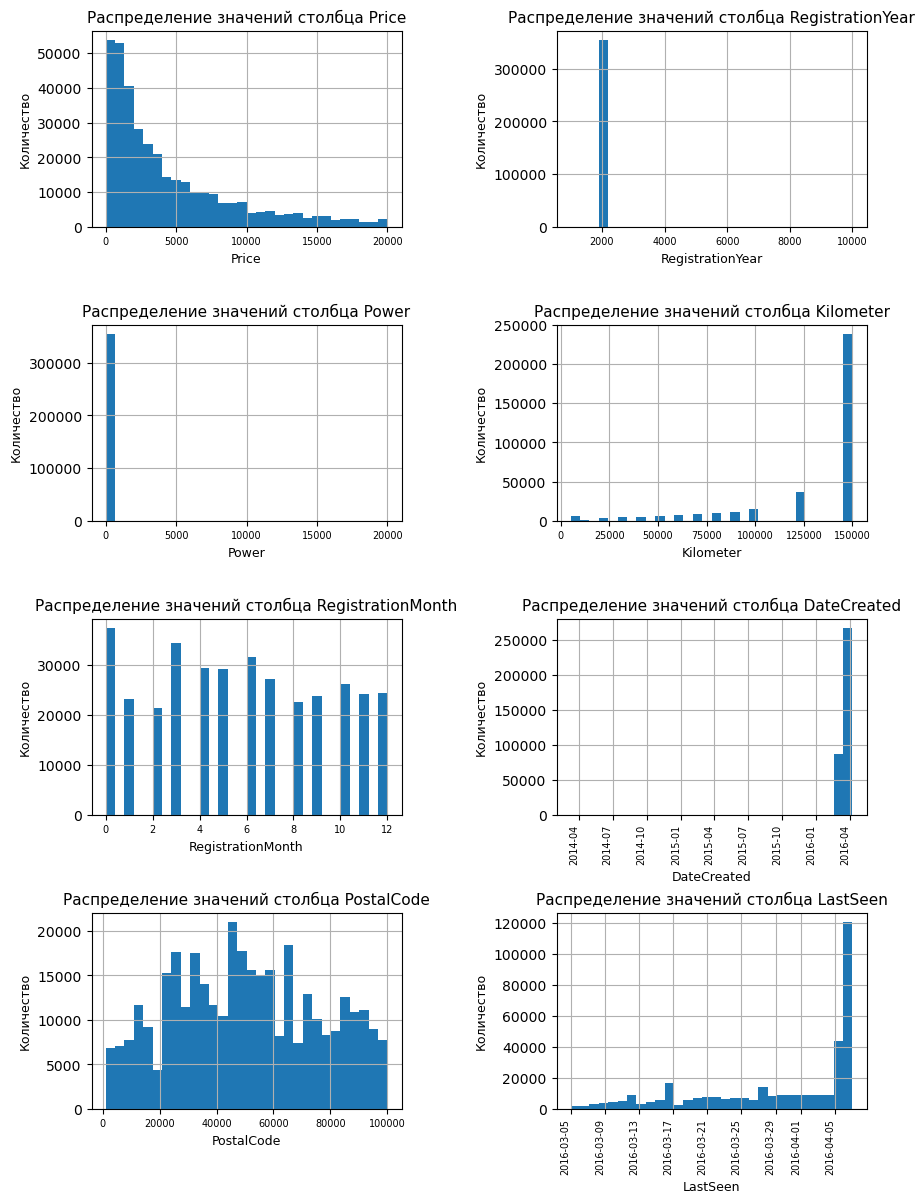

In [19]:
numerical_columns = ['Price', 'RegistrationYear', 'Power', 'Kilometer', 'RegistrationMonth', 'DateCreated', 'PostalCode', 'LastSeen']

fig = plt.figure(figsize=(10,14))

for i, column in enumerate(numerical_columns):
    curr_data = data[column]
    plt.subplot(4, 2, i+1)
    plt.hist(curr_data, bins=30)
    plt.title('Распределение значений столбца ' + column, fontsize=11)
    if column in ['DateCreated', 'LastSeen']:
        plt.xticks(rotation=90, ha='right', fontsize=7)
    else:
        plt.xticks(fontsize=7)
    plt.xlabel(column, fontsize=9)
    plt.ylabel('Количество', fontsize=9)
    plt.grid()
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

#### Визуализация редких значений

`RegistrationYear`

In [20]:
data['RegistrationYear'].quantile(0.001)

1957.0

Фильтруем по годам от 1960 (это квантиль уровня 0.1%) до 2026

Теоретически есть машина 1884 года выпуска, которая все еще на ходу, но подобные примеры только исказят предсказания модели

Количество записей = 527


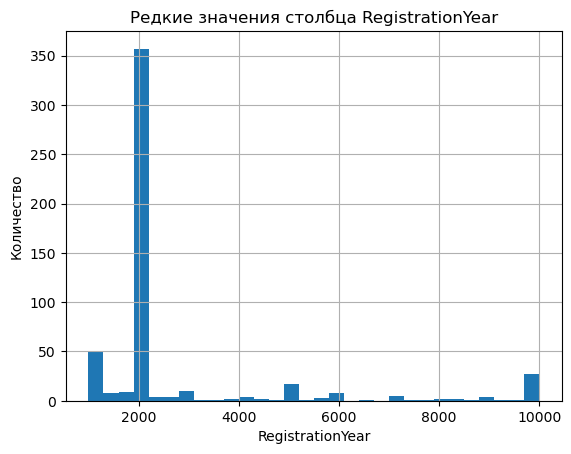

In [21]:
curr_data = data.loc[(data['RegistrationYear'] < 1960) | (data['RegistrationYear'] > 2026), :]
print('Количество записей =', curr_data.shape[0])
plt.hist(curr_data['RegistrationYear'], bins=30)
plt.title('Редкие значения столбца ' + 'RegistrationYear')
plt.xlabel('RegistrationYear')
plt.ylabel('Количество')
plt.grid()
plt.show()

Таких записей всего 171, удалим их

`Power`

0 лошадиных сил

Количество записей = 40225


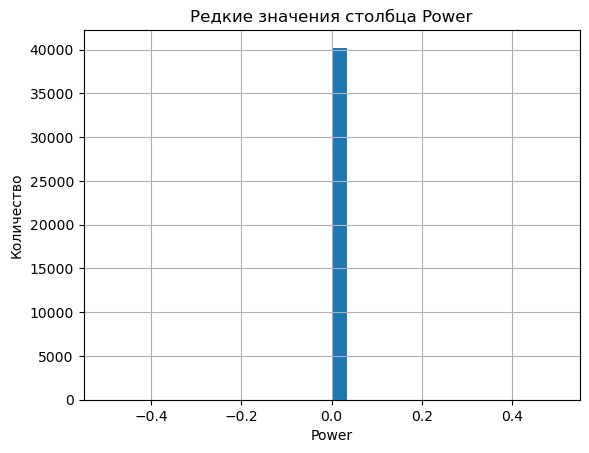

In [22]:
curr_data = data.loc[(data['Power'] == 0), :]
print('Количество записей =', curr_data.shape[0])
plt.hist(curr_data['Power'], bins=30)
plt.title('Редкие значения столбца ' + 'Power')
plt.xlabel('Power')
plt.ylabel('Количество')
plt.grid()
plt.show()

Равенство нулю мощности означает отсутствие информации о мощности автомобиля. Можно так и оставить

In [23]:
data['Power'].quantile(.999)

700.0

более 700 лошадиных сил (квантиль 99,9% примерно равна 500 л. с.)

Теоретически есть машины с заявленными значениями мощности до 5000, но такие примеры только ухудшат модель

Количество записей = 354


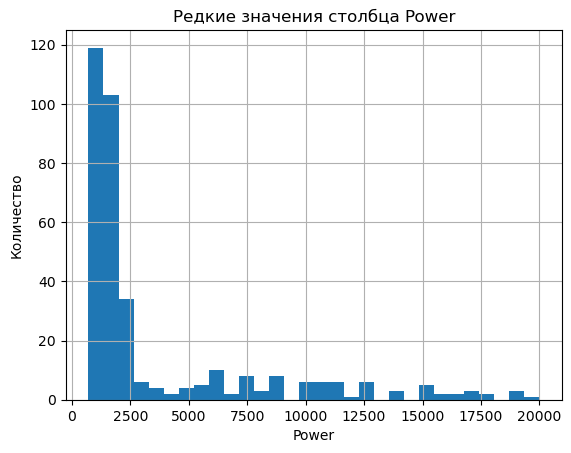

In [24]:
curr_data = data.loc[(data['Power'] > 700), :]
print('Количество записей =', curr_data.shape[0])
plt.hist(curr_data['Power'], bins=30)
plt.title('Редкие значения столбца ' + 'Power')
plt.xlabel('Power')
plt.ylabel('Количество')
plt.grid()
plt.show()

Такие мощности считаем выбросами и их небольшое количество - 354. Так что удалим их

`DateCreated`

In [25]:
data['DateCreated'].quantile(0.001)

Timestamp('2016-02-25 08:44:09.600000')

Удаляем все объявления, созданные раньше квантили

Удаляем

In [26]:
data = data[(data['RegistrationYear'] >= 1960) & (data['RegistrationYear'] <= 2026)]
data = data[data['Power'] <= 700]
data = data[data['DateCreated'] >= pd.Timestamp('2016-02-25 00:00:00')]

Повторно визуализируем распределение числовых столбцов

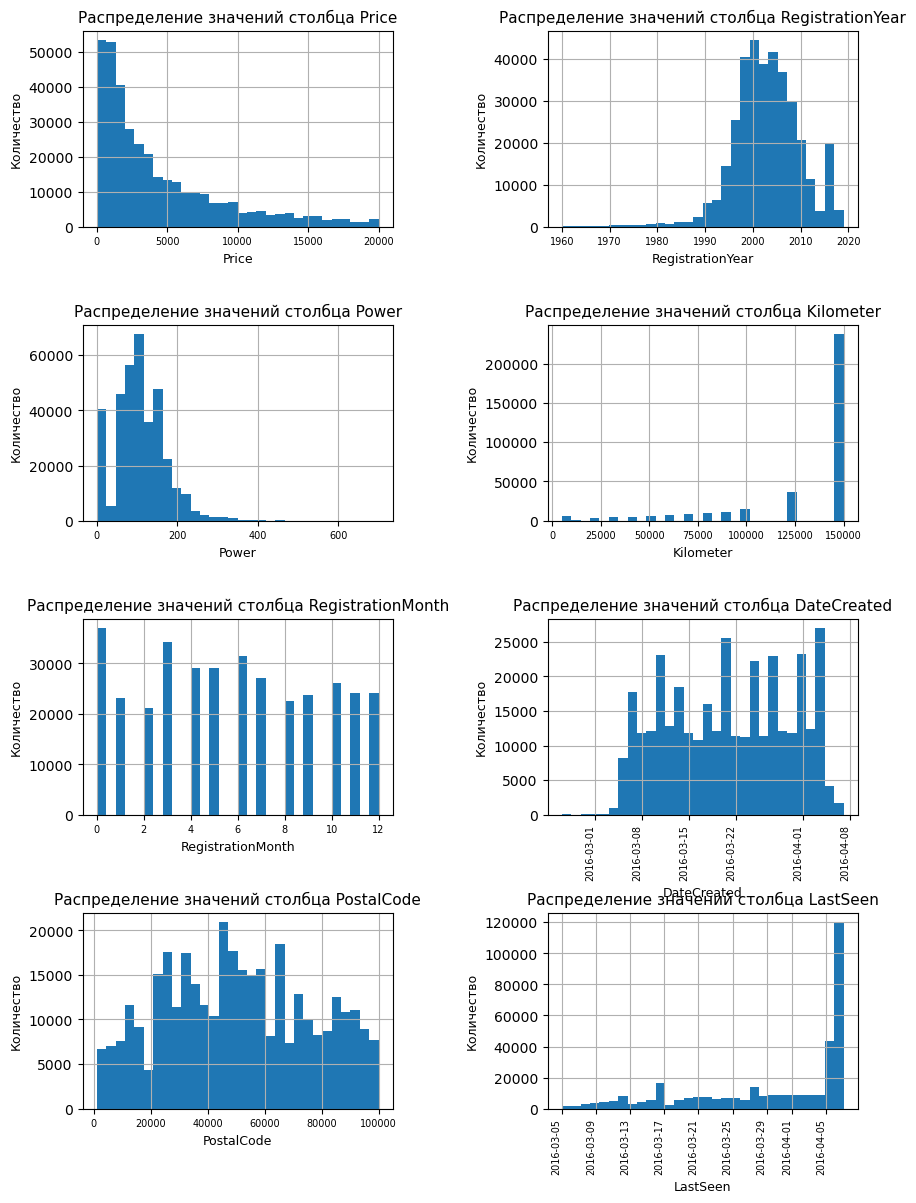

In [27]:
numerical_columns = ['Price', 'RegistrationYear', 'Power', 'Kilometer', 'RegistrationMonth', 'DateCreated', 'PostalCode', 'LastSeen']

fig = plt.figure(figsize=(10,14))

for i, column in enumerate(numerical_columns):
    curr_data = data[column]
    plt.subplot(4, 2, i+1)
    plt.hist(curr_data, bins=30)
    plt.title('Распределение значений столбца ' + column, fontsize=11)
    if column in ['DateCreated', 'LastSeen']:
        plt.xticks(rotation=90, ha='right', fontsize=7)
    else:
        plt.xticks(fontsize=7)
    plt.xlabel(column, fontsize=9)
    plt.ylabel('Количество', fontsize=9)
    plt.grid()
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

Преобразование даты в число

In [28]:
# Преобразование дат в количество дней (ОДИН РАЗ, ДО разделения на train/test)
base_date = pd.Timestamp("2016-01-01")
data['DateCreated'] = (data['DateCreated'] - base_date).dt.days
data['LastSeen'] = (data['LastSeen'] - base_date).dt.days

# Проверка типов
print("✅ DateCreated dtype:", data['DateCreated'].dtype)
print("✅ LastSeen dtype:", data['LastSeen'].dtype)

✅ DateCreated dtype: int64
✅ LastSeen dtype: int64


## Обучение моделей

#### Формирование выборок

In [29]:
RANDOM_STATE = 42

In [30]:
X = data.drop('Price', axis=1)
y = data['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)

Явно указываем категориальные признаки

In [31]:
values_and_type(X_train)

,column_name,type,value_1,value_2,value_3,value_4,value_5
0,VehicleType,object,sedan,small,wagon,unknown,bus
1,RegistrationYear,int64,2000,1999,2005,2001,2006
2,Gearbox,object,manual,auto,-,-,-
3,Power,int64,0,75,60,150,101
4,Model,object,golf,other,3er,unknown,polo
5,Kilometer,int64,150000,125000,100000,90000,80000
6,RegistrationMonth,int64,0,3,6,4,5
7,FuelType,object,petrol,gasoline,unknown,lpg,cng
8,Brand,object,volkswagen,opel,bmw,mercedes_benz,audi
9,Repaired,object,no,unknown,yes,-,-


Проверка правильности разделения на числовые и категориальные поля

In [32]:
categorical_columns = ['VehicleType', 
                       'Gearbox', 
                       'Model', 
                       'FuelType', 
                       'Brand', 
                       'Repaired']

numerical_columns = ['RegistrationYear', 
                     'Power', 'Kilometer', 
                     'RegistrationMonth', 
                     'DateCreated', 
                     'PostalCode', 
                     'LastSeen']

categorical_columns_indexes = [list(X_train.columns).index(cat_col) for cat_col in \
    categorical_columns]
print(X_train.columns)
print(categorical_columns_indexes)
values_and_type(X_train)
for column in X_train.columns:
    if column in categorical_columns:
        print(column, 'cat')
    elif column in numerical_columns:
        print(column, 'num')
    else:
        print(column, 'bad')

Index(['VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Model',
       'Kilometer', 'RegistrationMonth', 'FuelType', 'Brand', 'Repaired',
       'DateCreated', 'PostalCode', 'LastSeen'],
      dtype='object')
[0, 2, 4, 7, 8, 9]


,column_name,type,value_1,value_2,value_3,value_4,value_5
0,VehicleType,object,sedan,small,wagon,unknown,bus
1,RegistrationYear,int64,2000,1999,2005,2001,2006
2,Gearbox,object,manual,auto,-,-,-
3,Power,int64,0,75,60,150,101
4,Model,object,golf,other,3er,unknown,polo
5,Kilometer,int64,150000,125000,100000,90000,80000
6,RegistrationMonth,int64,0,3,6,4,5
7,FuelType,object,petrol,gasoline,unknown,lpg,cng
8,Brand,object,volkswagen,opel,bmw,mercedes_benz,audi
9,Repaired,object,no,unknown,yes,-,-


VehicleType cat
RegistrationYear num
Gearbox cat
Power num
Model cat
Kilometer num
RegistrationMonth num
FuelType cat
Brand cat
Repaired cat
DateCreated num
PostalCode num
LastSeen num


Создаем пайплайн предобработки для линейной регрессии

In [33]:
numeric_pipe_lr = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe_lr = Pipeline([
    ('OHE', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocess_lr = ColumnTransformer(
    [
        ('cat', categorical_pipe_lr, categorical_columns),
        ('num', numeric_pipe_lr, numerical_columns)
    ],
    remainder='drop'
    )


И пайплайн предобработки для остальных моделей

In [34]:
# Пайплайн для деревьев (DecisionTree, RandomForest)
numeric_pipe_tree = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median'))
])

categorical_pipe_tree = Pipeline([
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocess_tree = ColumnTransformer(
    [
        ('cat', categorical_pipe_tree, categorical_columns),
        ('num', numeric_pipe_tree, numerical_columns)
    ],
    remainder='drop'
)

# Пайплайн для LightGBM - кодируем категориальные (LightGBM работает с числами)
numeric_pipe_lgbm = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median'))
])

categorical_pipe_lgbm = Pipeline([
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocess_lgbm = ColumnTransformer(
    [
        ('cat', categorical_pipe_lgbm, categorical_columns),
        ('num', numeric_pipe_lgbm, numerical_columns)
    ],
    remainder='drop'
)

# Пайплайн для CatBoost - кодируем категориальные (работает с числами в pipeline)
numeric_pipe_catboost = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median'))
])

categorical_pipe_catboost = Pipeline([
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocess_catboost = ColumnTransformer(
    [
        ('cat', categorical_pipe_catboost, categorical_columns),
        ('num', numeric_pipe_catboost, numerical_columns)
    ],
    remainder='drop'
)

(Здесь по факту не нужно заполнять пропуски, т. к. это делалось ранее без пайплайна. Но для полноты пайплайна оставлю в нем шаг с заполнение пропусков)

Задаем словарь кортежей с названием, моделью и ее параметрами

In [35]:
pipe_parameters = {
    # Линейная регрессия
    "LinearRegression": (
        "LinearRegression",
        Pipeline([
            ('prep', preprocess_lr),
            ('model', LinearRegression(n_jobs=-1))
        ]),
        {}
    ),
    
    # Дерево решений
    "DecisionTree": (
        "DecisionTree",
        Pipeline([
            ('prep', preprocess_tree),
            ('model', DecisionTreeRegressor(
                max_depth=4,
                min_samples_split=3,
                min_samples_leaf=1,
                random_state=RANDOM_STATE
            ))
        ]),
        {
            'model__max_depth': distributions.IntDistribution(2, 12),
            'model__min_samples_split': distributions.IntDistribution(2, 12),
            'model__min_samples_leaf': distributions.IntDistribution(1, 12)
        }
    ),
    
    # Случайный лес
    "RandomForest": (
        "RandomForest",
        Pipeline([
            ('prep', preprocess_tree),
            ('model', RandomForestRegressor(
                n_estimators=500,
                max_depth=3,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        {
            'model__n_estimators': distributions.IntDistribution(100, 500, step=50),
            'model__max_depth': distributions.IntDistribution(2, 12),
            'model__min_samples_split': distributions.IntDistribution(2, 12),
            'model__min_samples_leaf': distributions.IntDistribution(1, 12)
        }
    ),
    
    # LightGBM
    "LightGBM": (
        "LightGBM",
        Pipeline([
            ('prep', preprocess_lgbm),
            ('model', LGBMRegressor(
                num_leaves=31,
                max_depth=-1,
                learning_rate=0.1,
                n_estimators=400,
                n_jobs=-1
            ))
        ]),
        {
            'model__num_leaves': distributions.IntDistribution(10, 60),
            'model__max_depth': distributions.IntDistribution(3, 12),
            'model__learning_rate': distributions.FloatDistribution(0.02, 0.2, log=True),
            'model__min_child_samples': distributions.IntDistribution(20, 100)
        }
    ),
    
    # CatBoost
    "CatBoost": (
        "CatBoost",
        Pipeline([
            ('prep', preprocess_catboost),
            ('model', CatBoostRegressor(
                iterations=400,
                random_seed=RANDOM_STATE,
                verbose=False,
                task_type='GPU',
                devices='0'
            ))
        ]),
        {
            'model__learning_rate': distributions.FloatDistribution(0.02, 0.2, log=True),
            'model__depth': distributions.IntDistribution(3, 12),
            'model__l2_leaf_reg': distributions.FloatDistribution(1, 50, log=True),
            'model__bagging_temperature': distributions.FloatDistribution(0, 1),
            'model__random_strength': distributions.FloatDistribution(0, 2)
        }
    )
}

Создаем кастомную функцию `objective` для `optuna`

In [36]:
def objective_with_timing(trial, params_dist, pipeline, X, y, cv_folds=3):
    """
    Objective function для Optuna.
    Возвращает RMSE и сохраняет время обучения.
    """
    # Выгружаем параметры из распределений
    params = {}
    for param_name, distribution in params_dist.items():
        if isinstance(distribution, distributions.FloatDistribution):
            params[param_name] = trial.suggest_float(
                param_name,
                distribution.low,
                distribution.high,
                log=distribution.log
            )
        elif isinstance(distribution, distributions.IntDistribution):
            params[param_name] = trial.suggest_int(
                param_name,
                distribution.low,
                distribution.high,
                step=getattr(distribution, 'step', 1)
            )
    
    # Клонируем и обновляем пайплайн
    current_pipeline = clone(pipeline)
    current_pipeline.set_params(**params)
    
    # Кросс-валидация с замером времени
    start_train = time.time()
    
    cv_results = cross_validate(
        current_pipeline, X, y,
        cv=cv_folds,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2'
        },
        n_jobs=-1
    )
    
    cv_time = time.time() - start_train
    
    # Метрики
    rmse = -cv_results['test_rmse'].mean()
    mae = -cv_results['test_mae'].mean()
    r2 = cv_results['test_r2'].mean()
    
    # Сохраняем в user_attrs
    trial.set_user_attr('cv_time', cv_time)
    trial.set_user_attr('rmse', rmse)
    trial.set_user_attr('mae', mae)
    trial.set_user_attr('r2', r2)
    
    return rmse

Задаем имена моделей, функций и вычислений для цикла далее

In [37]:
objectives_names = ["lr_objective", 
                    "dt_objective",
                    "rf_objective",
                    "lgbm_objective",
                    "catboost_objective"]

studies_names = ["lr_study", 
                "dt_study",
                "rf_study",
                "lgbm_study",
                "catboost_study"]

model_names = ["LinearRegression",
                "DecisionTree",
                "RandomForest",
                "LightGBM",
                "CatBoost"]

Поиск лучших наборов гиперпараметров моделей на кросс-валидации

In [ ]:
model_names = ["LinearRegression", "DecisionTree", "RandomForest", "LightGBM", "CatBoost"]
results = {}

for model_name in model_names:
    print(f"\n{'='*60}")
    print(f"  ОПТИМИЗАЦИЯ: {model_name}")
    print(f"{'='*60}")
    
    _, pipeline, params_dist = pipe_parameters[model_name]
    
    # Если нет параметров для оптимизации (LinearRegression)
    if not params_dist:
        print("   Нет параметров для оптимизации")

        start = time.time()
        cv_results = cross_validate(
        pipeline, X_train, y_train,
        cv=3,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2'
        },
        n_jobs=-1
        )
        cv_time = time.time() - start
        
        rmse_cv = -cv_results['test_rmse'].mean()
        mae_cv = -cv_results['test_mae'].mean()
        r2_cv = cv_results['test_r2'].mean()
        
        results[model_name] = {
            'rmse cv': rmse_cv,
            'mae cv': mae_cv,
            'r2 cv': r2_cv,
            'cv time': cv_time,
            'n trials': 1
        }
        
        print(f"   RMSE: {rmse_cv:.2f} | MAE: {mae_cv:.2f} | R²: {r2_cv:.4f}")
        
        
        
    else:
        # Создаем Study
        study = optuna.create_study(direction='minimize')
        
        # Objective function с параметрами
        objective_func = partial(
            objective_with_timing,
            params_dist=params_dist,
            pipeline=pipeline,
            X=X_train,
            y=y_train,
            cv_folds=3
        )
        
        # Оптимизируем
        study.optimize(objective_func, n_trials=15, show_progress_bar=False)
        
        # Лучший trial
        best_trial = study.best_trial
        
        results[model_name] = {
            'rmse cv': best_trial.value,
            'mae cv': best_trial.user_attrs['mae'],
            'r2 cv': best_trial.user_attrs['r2'],
            'cv time': best_trial.user_attrs['cv_time'],
            'params': best_trial.params,
            'n trials': len(study.trials)
        }
        
        print(f"   RMSE: {best_trial.value:.2f} | MAE: {best_trial.user_attrs['mae']:.2f} | R²: {best_trial.user_attrs['r2']:.4f}")
        print(f"\n   Лучшие параметры:")
        for key, val in best_trial.params.items():
            print(f"     {key}: {val}")

print(f"\n{'='*60}")
print("ИТОГОВОЕ СРАВНЕНИЕ")
print(f"{'='*60}")

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('rmse cv')
print(results_df[['rmse cv', 'mae cv', 'r2 cv', 'cv time']])


  ОПТИМИЗАЦИЯ: LinearRegression
   Нет параметров для оптимизации


[I 2026-03-18 15:49:20,879] A new study created in memory with name: no-name-4190eee2-23cd-4f3b-bd2b-a23601aab965



  ОПТИМИЗАЦИЯ: DecisionTree


[I 2026-03-18 15:49:22,892] Trial 0 finished with value: 2108.746032134202 and parameters: {'model__max_depth': 12, 'model__min_samples_split': 9, 'model__min_samples_leaf': 1}. Best is trial 0 with value: 2108.746032134202.
[I 2026-03-18 15:49:24,521] Trial 1 finished with value: 2167.550800397677 and parameters: {'model__max_depth': 9, 'model__min_samples_split': 3, 'model__min_samples_leaf': 6}. Best is trial 0 with value: 2108.746032134202.
[I 2026-03-18 15:49:25,964] Trial 2 finished with value: 2531.7172180237917 and parameters: {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__min_samples_leaf': 9}. Best is trial 0 with value: 2108.746032134202.
[I 2026-03-18 15:49:27,662] Trial 3 finished with value: 2134.251649631003 and parameters: {'model__max_depth': 10, 'model__min_samples_split': 8, 'model__min_samples_leaf': 1}. Best is trial 0 with value: 2108.746032134202.
[I 2026-03-18 15:49:29,181] Trial 4 finished with value: 2408.7828129626637 and parameters: {'model__

   RMSE: 2084.73 | MAE: 1285.89 | R²: 0.7864

   Лучшие параметры:
     model__max_depth: 12
     model__min_samples_split: 11
     model__min_samples_leaf: 4

  ОПТИМИЗАЦИЯ: RandomForest


...

   RMSE: 1909.06 | MAE: 1190.12 | R²: 0.8209

   Лучшие параметры:
     model__n_estimators: 350
     model__max_depth: 12
     model__min_samples_split: 9
     model__min_samples_leaf: 7

  ОПТИМИЗАЦИЯ: LightGBM


[I 2026-03-18 15:56:13,096] Trial 0 finished with value: 1812.1409712215125 and parameters: {'model__num_leaves': 47, 'model__max_depth': 12, 'model__learning_rate': 0.02085859584095075, 'model__min_child_samples': 83}. Best is trial 0 with value: 1812.1409712215125.
[I 2026-03-18 15:56:15,472] Trial 1 finished with value: 1740.2814112273093 and parameters: {'model__num_leaves': 24, 'model__max_depth': 5, 'model__learning_rate': 0.1463136801604609, 'model__min_child_samples': 46}. Best is trial 1 with value: 1740.2814112273093.
[I 2026-03-18 15:56:18,426] Trial 2 finished with value: 1823.1130844069457 and parameters: {'model__num_leaves': 50, 'model__max_depth': 5, 'model__learning_rate': 0.04073176605011836, 'model__min_child_samples': 87}. Best is trial 1 with value: 1740.2814112273093.
[I 2026-03-18 15:56:22,399] Trial 3 finished with value: 1785.4592757286573 and parameters: {'model__num_leaves': 52, 'model__max_depth': 9, 'model__learning_rate': 0.025667751974057587, 'model__min_

   RMSE: 1708.49 | MAE: 1036.74 | R²: 0.8566

   Лучшие параметры:
     model__num_leaves: 40
     model__max_depth: 10
     model__learning_rate: 0.12239048454629044
     model__min_child_samples: 25

  ОПТИМИЗАЦИЯ: CatBoost


[I 2026-03-18 15:59:19,110] Trial 0 finished with value: 1892.2059380346175 and parameters: {'model__learning_rate': 0.02170688065297441, 'model__depth': 8, 'model__l2_leaf_reg': 12.461089398152557, 'model__bagging_temperature': 0.7216661072534611, 'model__random_strength': 1.6399586731999911}. Best is trial 0 with value: 1892.2059380346175.
[I 2026-03-18 16:01:39,636] Trial 1 finished with value: 1739.5172620562537 and parameters: {'model__learning_rate': 0.06291734920641955, 'model__depth': 10, 'model__l2_leaf_reg': 4.0088606826134665, 'model__bagging_temperature': 0.2748400796101691, 'model__random_strength': 0.7233965760856986}. Best is trial 1 with value: 1739.5172620562537.
[I 2026-03-18 16:03:46,550] Trial 2 finished with value: 1736.8931626955862 and parameters: {'model__learning_rate': 0.06956339606879289, 'model__depth': 10, 'model__l2_leaf_reg': 4.441741029784928, 'model__bagging_temperature': 0.668150451370566, 'model__random_strength': 0.9480269799355647}. Best is trial 2 

   RMSE: 1706.71 | MAE: 1032.46 | R²: 0.8569

   Лучшие параметры:
     model__learning_rate: 0.12345424183744799
     model__depth: 12
     model__l2_leaf_reg: 12.561137377021248
     model__bagging_temperature: 0.28954501929576626
     model__random_strength: 1.991451731076726

ИТОГОВОЕ СРАВНЕНИЕ
                      rmse cv       mae cv     r2 cv     cv time
CatBoost          1706.706283  1032.457284  0.856866  167.915177
LightGBM          1708.491829  1036.737695  0.856565    2.966927
RandomForest      1909.055649  1190.120631  0.820914   35.162981
DecisionTree      2084.727693  1285.892715  0.786419    1.224238
LinearRegression  2719.930317  1902.386827   0.63647    9.048592


  ИТОГОВОЕ СРАВНЕНИЕ

| Модель               | rmse cv     | mae cv      | r2 cv      | cv time    |
|----------------------|-------------|-------------|------------|------------|
| CatBoost             | 1706.706283 | 1032.457284 | 0.856866   | 167.915177 |
| LightGBM             | 1708.491829 | 1036.737695 | 0.856565   | 2.966927   |
| RandomForest         | 1909.055649 | 1190.120631 | 0.820914   | 35.162981  |
| DecisionTree         | 2084.727693 | 1285.892715 | 0.786419   | 1.224238   |
| LinearRegression     | 2719.930317 | 1902.386827 | 0.63647    | 9.048592   |

МОДЕЛИ С ЛУЧШИМИ ПАРАМЕТРАМИ

`LinearRegression`

RMSE: 2735.65 | MAE: 1905.64 | R²: 0.6326

Нет параметров

`DecisionTree`

RMSE: 2084.73 | MAE: 1285.89 | R²: 0.7864

Лучшие параметры:
* model__max_depth: 12
* model__min_samples_split: 11
* model__min_samples_leaf: 4

`RandomForest`

RMSE: 1909.06 | MAE: 1190.12 | R²: 0.8209

Лучшие параметры:
* model__n_estimators: 350
* model__max_depth: 12
* model__min_samples_split: 9
* model__min_samples_leaf: 7

`LightGBM`

RMSE: 1708.49 | MAE: 1036.74 | R²: 0.8566

Лучшие параметры:
* model__num_leaves: 40
* model__max_depth: 10
* model__learning_rate: 0.12239048454629044
* model__min_child_samples: 25

`CatBoost`

RMSE: 1706.71 | MAE: 1032.46 | R²: 0.8569

Лучшие параметры:
* model__learning_rate: 0.12345424183744799
* model__depth: 12
* model__l2_leaf_reg: 12.561137377021248
* model__bagging_temperature: 0.28954501929576626
* model__random_strength: 1.991451731076726

### Обучение лучших моделей на тестовой выборке

In [39]:
for model_name in model_names:
    _, pipeline_base, _ = pipe_parameters[model_name]
    pipeline = clone(pipeline_base)
    best_params = results[model_name].get('params', {})
    pipeline.set_params(**best_params)
    
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start
    
    start = time.time()
    y_pred = pipeline.predict(X_test)
    test_time = time.time() - start
    
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[model_name]['Train time'] = train_time
    results[model_name]['Test time'] = test_time
    results[model_name]['rmse test'] = rmse
    results[model_name]['mae test'] = mae
    results[model_name]['r2 test'] = r2
    
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('rmse cv')
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ')
display(results_df[['rmse cv', 'mae cv', 'r2 cv', 'cv time', 'rmse test', 'mae test', 'r2 test', 'Train time', 'Test time']])

print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ КАЧЕСТВА ПРЕДСКАЗАНИЯ, ВРЕМЕНИ ОБУЧЕНИЯ И ВРЕМЕНИ ПРЕДСКАЗАНИЯ")

display(results_df[['rmse cv', 'rmse test','Train time', 'Test time']])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 973
[LightGBM] [Info] Number of data points in the train set: 264872, number of used features: 13
[LightGBM] [Info] Start training from score 4416.577536


c:\ProgramData\anaconda3\envs\project_shift\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


ИТОГОВЫЕ РЕЗУЛЬТАТЫ


,rmse cv,mae cv,r2 cv,cv time,rmse test,mae test,r2 test,Train time,Test time
CatBoost,1706.706283,1032.457284,0.856866,167.915177,1670.578354,1009.633726,0.862982,6.69259,0.233144
LightGBM,1708.491829,1036.737695,0.856565,2.966927,1681.465562,1022.854661,0.861191,1.141826,0.176033
RandomForest,1909.055649,1190.120631,0.820914,35.162981,1883.322941,1178.231213,0.825862,18.530751,0.231184
DecisionTree,2084.727693,1285.892715,0.786419,1.224238,2032.304024,1260.127621,0.797222,1.048383,0.070542
LinearRegression,2719.930317,1902.386827,0.63647,9.048592,2735.653876,1905.635665,0.632578,4.034266,0.182596


ИТОГОВЫЕ РЕЗУЛЬТАТЫ КАЧЕСТВА ПРЕДСКАЗАНИЯ, ВРЕМЕНИ ОБУЧЕНИЯ И ВРЕМЕНИ ПРЕДСКАЗАНИЯ


,rmse cv,rmse test,Train time,Test time
CatBoost,1706.706283,1670.578354,6.69259,0.233144
LightGBM,1708.491829,1681.465562,1.141826,0.176033
RandomForest,1909.055649,1883.322941,18.530751,0.231184
DecisionTree,2084.727693,2032.304024,1.048383,0.070542
LinearRegression,2719.930317,2735.653876,4.034266,0.182596


| Модель           | rmse cv     | mae cv      | r2 cv       | cv time     | rmse test   | mae test    | r2 test    | Train time | Test time  |
|------------------|-------------|-------------|-------------|-------------|-------------|-------------|------------|------------|------------|
| CatBoost         | 1706.706283 | 1032.457284 | 0.856866    | 167.915177  | 1670.578354 | 1009.633726 | 0.862982   | 6.692590   | 0.233144   |
| LightGBM         | 1708.491829 | 1036.737695 | 0.856565    | 2.966927    | 1681.465562 | 1022.854661 | 0.861191   | 1.141826   | 0.176033   |
| RandomForest     | 1909.055649 | 1190.120631 | 0.820914    | 35.162981   | 1883.322941 | 1178.231213 | 0.825862   | 18.530751  | 0.231184   |
| DecisionTree     | 2084.727693 | 1285.892715 | 0.786419    | 1.224238    | 2032.304024 | 1260.127621 | 0.797222   | 1.048383   | 0.070542   |
| LinearRegression | 2719.930317 | 1902.386827 | 0.636470    | 9.048592    | 2735.653876 | 1905.635665 | 0.632578   | 4.034266   | 0.182596   |

| Модель           | rmse cv     | rmse test   | Train time | Test time  |
|------------------|-------------|-------------|------------|------------|
| CatBoost         | 1706.706283 | 1670.578354 | 6.692590   | 0.233144   |
| LightGBM         | 1708.491829 | 1681.465562 | 1.141826   | 0.176033   |
| RandomForest     | 1909.055649 | 1883.322941 | 18.530751  | 0.231184   |
| DecisionTree     | 2084.727693 | 2032.304024 | 1.048383   | 0.070542   |
| LinearRegression | 2719.930317 | 2735.653876 | 4.034266   | 0.182596   |

## Анализ моделей

Требовалось выбрать модель, которая будет оптимальной по следующим критериям:
* качество предсказания
* время обучения модели
* время предсказания модели

Были проанализированы следующие модели:
* Линейная регрессия
* Дерево решений
* Случайный лес
* Градиентный бустинг (CatBoost и LightGBM)

Результаты обучения моделей с наилучшими найденными наборами гиперпараметров представлены в таблице:

| Модель           | rmse cv     | rmse test   | Train time | Test time  |
|------------------|-------------|-------------|------------|------------|
| CatBoost         | 1706.706283 | 1670.578354 | 6.692590   | 0.233144   |
| LightGBM         | 1708.491829 | 1681.465562 | 1.141826   | 0.176033   |
| RandomForest     | 1909.055649 | 1883.322941 | 18.530751  | 0.231184   |
| DecisionTree     | 2084.727693 | 2032.304024 | 1.048383   | 0.070542   |
| LinearRegression | 2719.930317 | 2735.653876 | 4.034266   | 0.182596   |

Двумя наилучшими моделями оказались модели градиентного бустинга - `CatBoost` и `LightGBM`. Их значения целевой метрики `RMSE` оказались значительно ниже, чем у другим моделей - `RMSE = 1670` и `RMSE = 1681` против наименьшего значения `RMSE = 1883` у модели случайного леса. Далее необходимо сделать выбор из этих двух моделей, т.к. они обладают наилучшими значениями целевой метрики.

Для двух лучших моделей имеем: 

| Модель           | качество предсказания | время обучения | время предсказания |
|------------------|-------------|------------|------------|
| CatBoost         | 1670.578354 | 6.692590   | 0.233144   |
| LightGBM         | 1681.465562 | 1.141826   | 0.176033   |

Имеем уменьшения значения целевой метрики на `10 единиц` при увеличении времени обучения в `6 раз`, время предсказания для обоих моделей сопоставимо, так что его учитывать не будем. Прирост значения метрики на 10 единиц довольно мал, но при текущем размере датасета имеет смысл использовать `CatBoost`, т. к. и `1 секунда` и `7 секунд` - это довольно быстро. При наличии большего объема, на котором время обучения может составлять часы или даже дни будет иметь смысл использовать `LightGBM`, т. к. прирост значения метрики незначителен, а время обучения растет в `6 раз`.

## Чек-лист проверки

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [ ]  Весь код выполняется без ошибок
- [ ]  Ячейки с кодом расположены в порядке исполнения
- [ ]  Выполнена загрузка и подготовка данных
- [ ]  Выполнено обучение моделей
- [ ]  Есть анализ скорости работы и качества моделей

P. S. В задании не было явно сказано, как считать метрику - на кросс валидации или на тесте. Я сделал выводы по значениям метрики на тесте, но, вообще говоря, выводы будут точно такими же при рассмотрении значений метрики на кросс-валидации.